<a href="https://colab.research.google.com/github/ai-with-sam/LearnPandas/blob/main/Pandas_SQLipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd

# Step 1: Create a CONNECTION to a database.
# ':memory:' means "don't save to disk — build the database in RAM, just for this session"
conn = sqlite3.connect(':memory:')

print("Connection created:", conn)

Connection created: <sqlite3.Connection object at 0x78dfa174e2f0>


In [2]:
# Step 2: Get some data into the database.
# We'll build two small DataFrames first (Customers and Orders), then load them as SQL tables.

customers = pd.DataFrame({
    'customer_id': ['C1', 'C2', 'C3', 'C4', 'C5'],
    'name':        ['Alice', 'Bob', 'Charlie', 'Diana', 'Evan'],
    'city':        ['Mumbai', 'Delhi', 'Mumbai', 'Bangalore', 'Delhi'],
    'tier':        ['Gold', 'Silver', 'Gold', 'Silver', 'Gold']
})

orders = pd.DataFrame({
    'order_id':    ['O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7'],
    'customer_id': ['C1', 'C2', 'C1', 'C3', 'C4', 'C6', 'C2'],   # Note: C6 has no matching customer!
    'product':     ['Laptop', 'Chair', 'Mouse', 'Desk', 'Phone', 'Tablet', 'Monitor'],
    'amount':      [55000, 8000, 1200, 15000, 32000, 22000, 18000],
    'order_date':  ['2025-01-10', '2025-01-15', '2025-02-01', '2025-02-10',
                     '2025-03-01', '2025-03-05', '2025-03-10']
})

# Step 3: Load each DataFrame into the database AS A TABLE.
# if_exists='replace' means: if a table with this name already exists, overwrite it.
customers.to_sql('customers', conn, index=False, if_exists='replace')
orders.to_sql('orders', conn, index=False, if_exists='replace')

print("Tables created inside the database.")

Tables created inside the database.


In [3]:
customers

,customer_id,name,city,tier
0,C1,Alice,Mumbai,Gold
1,C2,Bob,Delhi,Silver
2,C3,Charlie,Mumbai,Gold
3,C4,Diana,Bangalore,Silver
4,C5,Evan,Delhi,Gold


In [4]:
orders

,order_id,customer_id,product,amount,order_date
0,O1,C1,Laptop,55000,2025-01-10
1,O2,C2,Chair,8000,2025-01-15
2,O3,C1,Mouse,1200,2025-02-01
3,O4,C3,Desk,15000,2025-02-10
4,O5,C4,Phone,32000,2025-03-01
5,O6,C6,Tablet,22000,2025-03-05
6,O7,C2,Monitor,18000,2025-03-10


In [6]:
# Step 4: Write a helper so we don't repeat ourselves on every query
def sql(query):
    """Run a SQL query against our database and return the result as a Pandas DataFrame."""
    return pd.read_sql_query(query, conn)

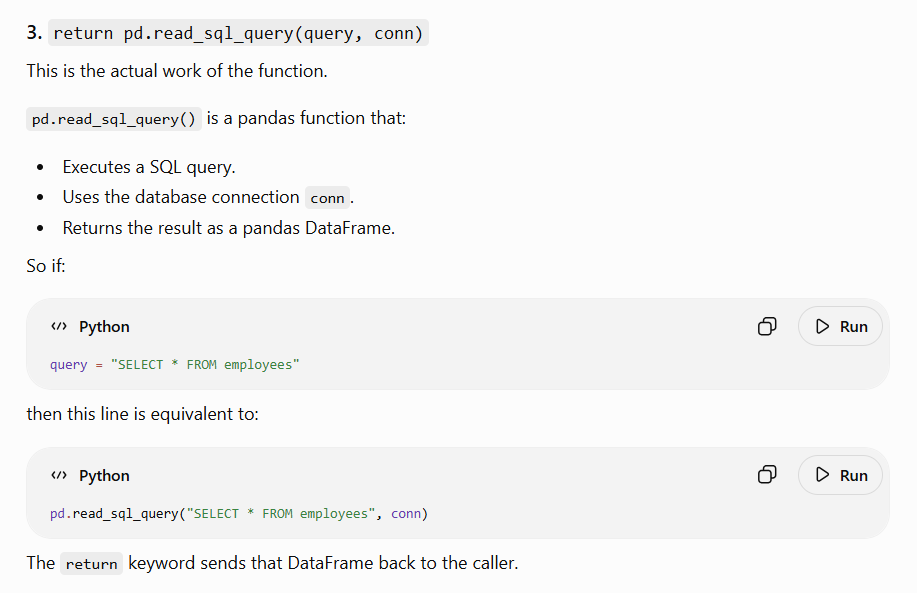

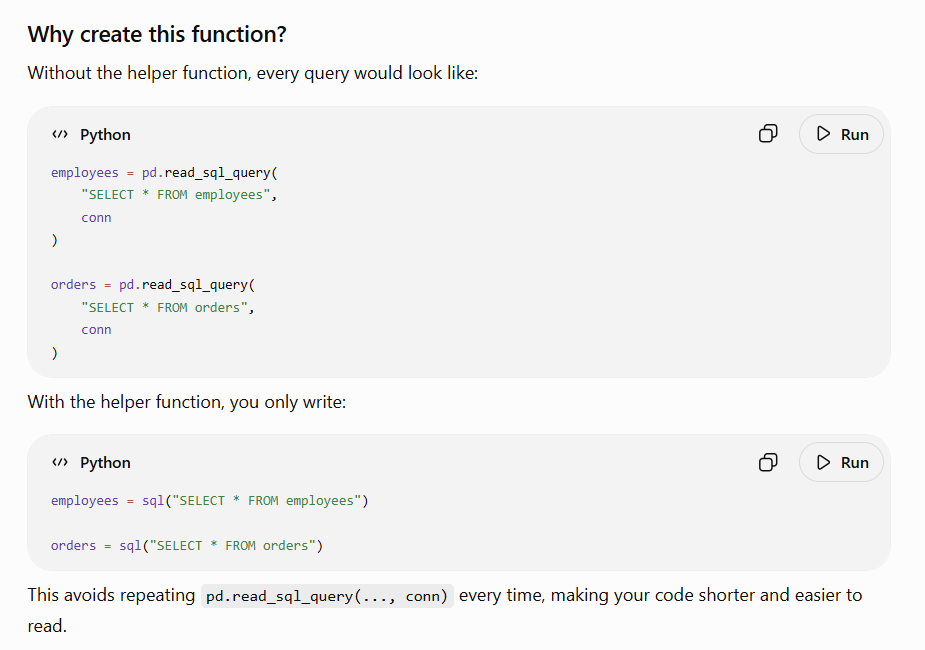

In [12]:
customers = sql("select name,city from customers")
customers

,name,city
0,Alice,Mumbai
1,Bob,Delhi
2,Charlie,Mumbai
3,Diana,Bangalore
4,Evan,Delhi


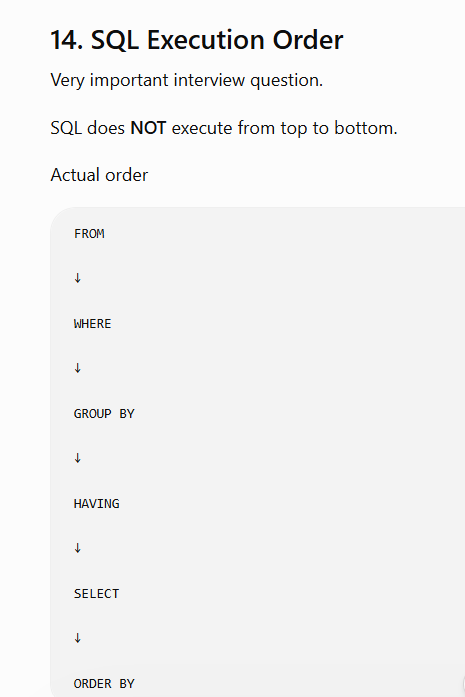

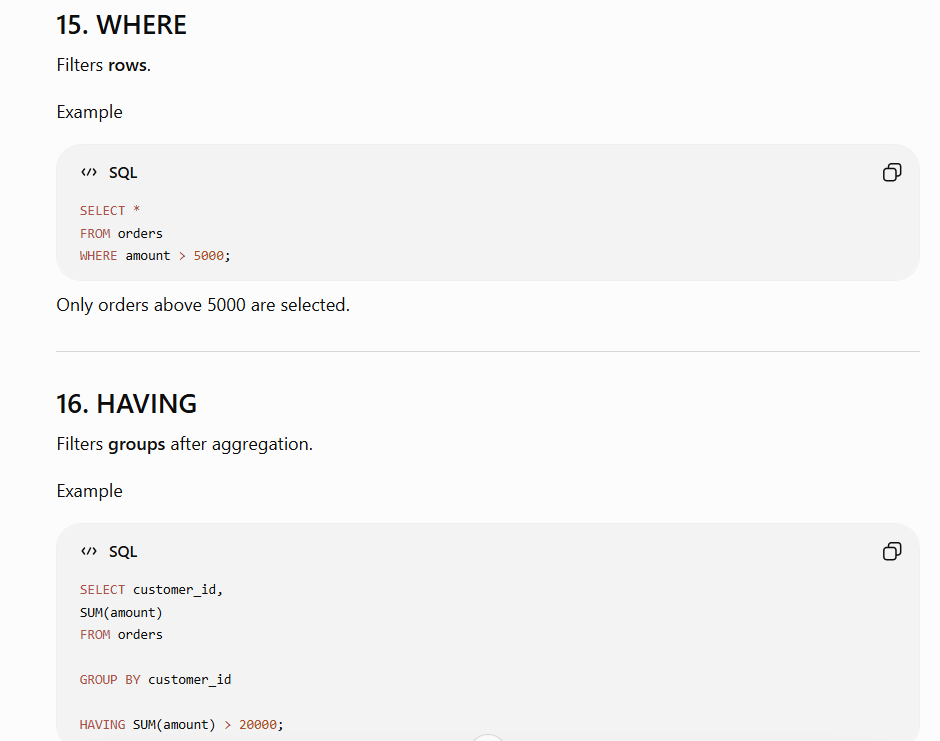

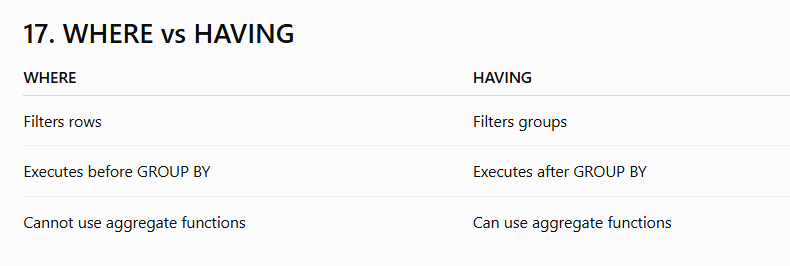

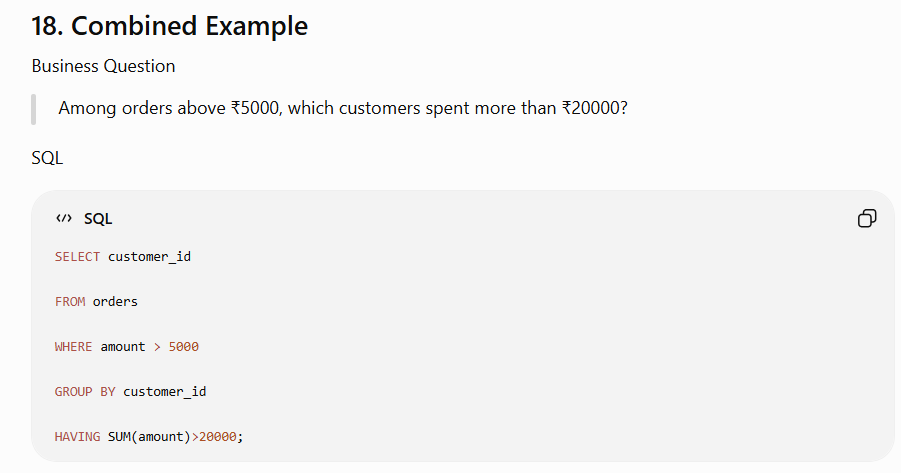